# <center>ASTR4004/8004 - Inference - Part 1</center> 

## Bayes' theorem:
$$
P(\theta|D)=P(D|\theta)\frac{P(\theta)}{P(D)}
$$

* $P(D|\theta)$: the likelihood function, representing the probability of observing the data ($D$) given a specific set of modeling parameters ($\theta$)
* $P(\theta)$: the prior probability distribution over the modeling parameters ($\theta$). This represents our initial beliefs of possible values of $\theta$
* $P(D)$: the marginal likelihood (Bayesian evidence), obtained by summing over a discrete parameter or integrating over a continuous one: $P(D)=\sum_{\theta}P(D|\theta)P(\theta)$ or $P(D)=\int P(D|\theta)P(\theta)\,\mathrm{d}\theta$
* $P(\theta|D)$: the posterior probability distribution over the modeling parameters ($\theta$) given the data.

This notebook fits the distribution of a dataset within a Bayesian framework. The model considered here is a Normal distribution with a fixed mean and an unknown standard deviation.

## Useful packages

In [17]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import cumulative_trapezoid
from scipy.special import logsumexp

## Data (D) and the task
We will be given a dataset and the task is to find a distribution to fit it

Text(0, 0.5, 'PDF')

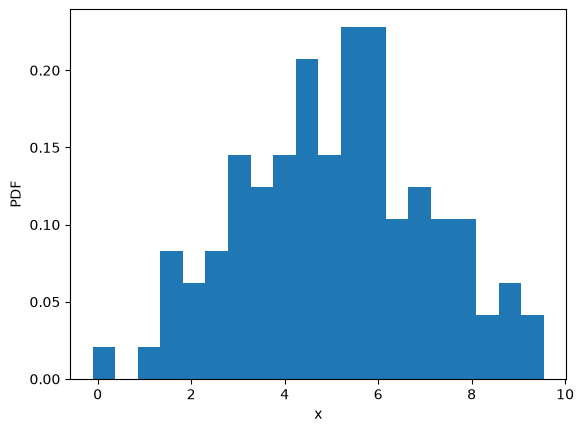

In [18]:
# Set seed for reproducibility
np.random.seed(0)

# Generate dataset (100 data points) following a normal distribution
mean_real, std_real = 5, 2
n_data = 100
data = np.random.normal(loc=mean_real, scale=std_real, size=n_data)
plt.hist(data, bins=20, density=True)
plt.xlabel('x')
plt.ylabel('PDF')

## Propose your model
* The histogram suggests that our dataset $D$ may follow a Normal distribution, so we adopt that as our model.
* To begin with a one-parameter problem, we fix the mean to a visually estimated value.
* Our parameter $\theta$ is therefore the standard deviation $\sigma$ (`std`).

## Write a generic function to sample from a 1D parameter space (`x`) based on any given `pdf(x)`

### inverse CDF sampling
Also known as the inverse transform sampling method, it is a technique used to generate random samples from a probability distribution given its cumulative distribution function:
* The cumulative distribution function $F(x)$ of a random variable $X$ describes the probability that $X$ takes on a value less than or equal to $x$: $$F(x)=P(X\leq x)$$
* Generate a random number $U$ from a uniform distribution over the interval [0,1], which represents a probability.
* Use the inverse CDF, $F^{-1}$, to transform the uniform random variable: $$X=F^{-1}(U).$$ This transformation ensures that $X$ follows the target distribution.
* Example: for an exponential distribution, $$F(x)=1-e^{-\lambda x},\qquad F^{-1}(u)=-\frac{1}{\lambda}\ln(1-u).$$
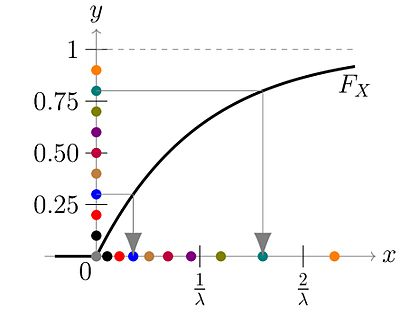

In [19]:
def sample_parameters(pdf, x_min, x_max, num_samples):
    '''
    Inverse CDF sampling

    Parameters:
    - pdf: the target PDF to sample
    - x_min, x_max: range to sample 
    - num_samples: the number of samples to generate

    Return:
    - x_samples: samples that follow the given PDF
    '''
    
    xs = np.linspace(x_min, x_max, 2000)
    pdfs = np.array([pdf(x) for x in xs], dtype=float)

    if not np.all(np.isfinite(pdfs)) or np.any(pdfs < 0):
        raise ValueError('The PDF must be finite and non-negative.')

    cdf = cumulative_trapezoid(pdfs, xs, initial=0.0)
    if cdf[-1] <= 0:
        raise ValueError('The PDF has zero integral over the sampling range.')
    cdf /= cdf[-1]

    # Remove flat CDF sections caused by zero-density regions. For each
    # plateau, retain its right edge; for the final plateau retain its
    # left edge so no samples leak beyond the PDF support.
    cdf_unique, first = np.unique(cdf, return_index=True)
    last = np.concatenate((first[1:] - 1, [len(cdf) - 1]))
    last[-1] = first[-1]
    xs_unique = xs[last]

    uniform_samples = np.random.uniform(0, 1, num_samples)
    x_samples = np.interp(uniform_samples, cdf_unique, xs_unique)

    return x_samples

### uniform between $x\in[-1,1]$

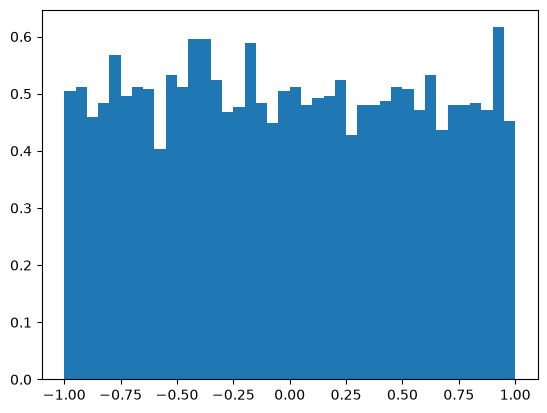

In [20]:
def pdf(x):
    if x<-1 or x>1:
        return 0
    else:
        return 0.5
    
x_samples = sample_parameters(pdf, -1, 1, 5000)
assert np.all((-1 <= x_samples) & (x_samples <= 1))
plt.hist(x_samples, density=True, bins=40);

## Normal distribution

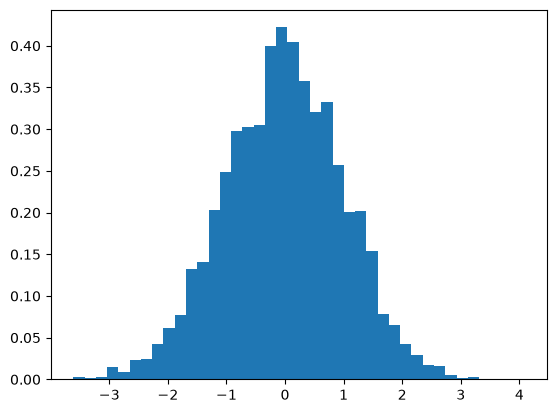

In [21]:
def norm_pdf(x, mean, std):
    return np.exp(-((x - mean) / std)**2 / 2) / (std * np.sqrt(2 * np.pi))

def pdf(x):
    return norm_pdf(x,0,1)
    
x_samples = sample_parameters(pdf, -5, 5, 5000)
plt.hist(x_samples, density=True, bins=40);

## Define the prior of your model parameters

In [22]:
std_min, std_max   = 1, 3

# A uniform prior within the stated bounds and zero outside them
def initial_prior(std):
    if std_min <= std <= std_max:
        return 1.0 / (std_max - std_min)
    return 0.0

## Calculate the likelihood 
We have picked the Normal distribution as our model, then for a given set of model parameters, $\theta$ or $\sigma$ (`std`), the likelihood function of data $D$ or `x` is simply 
$$
P(D|\theta) \equiv P(x|\sigma) = \frac{1}{\sqrt{2\pi}\sigma}\exp{\left[-\frac{1}{2}\left(\frac{x-\mu}{\sigma}\right)^2\right]}.
$$
Note that here we assume we know what the mean ($\mu$) is.

In [23]:
def likelihood(x, mean, std):
    return norm_pdf(x, mean, std)

## A bit of a detour - Monte Carlo

Before jumping into Bayesian inference, it is worth reviewing *why* Monte Carlo is such an important tool for generating samples from the posterior. Let's start with plain Monte Carlo sampling.

Consider the problem where we have some parameter $x$ that follows some distribution function $p$ (e.g. uniform, Normal or any unknown shape). Let's say we would like to compute the expectation value of a function that depends on $x$, $g(x)$, defined as 

\begin{equation}
\mathbb{E}_{p(x)}\left[g(x)\right]= \int g(x)\,p(x)\,dx.
\end{equation}

In the case of complex (or unknown) $p(x)$, this integration can be challenging and/or costly to compute. The Monte Carlo approximation allows us to estimate the integral above using discrete samples drawn from $p(x)$, i.e.

\begin{equation}
\mathbb{E}_{p(x)}\left[g(x)\right] \approx \frac{1}{N} \sum_{n=1}^{N} g(x^{(n)}).
\end{equation}

If samples are independent, then the variance on the mean is given by

\begin{equation}
\sigma^2 = \frac{1}{N} {\rm Var}_{p(x)}\left[g(x)\right],
\end{equation}

so the variance of the Monte Carlo estimate decreases as the number of independent samples increases.

## Bayesian inference

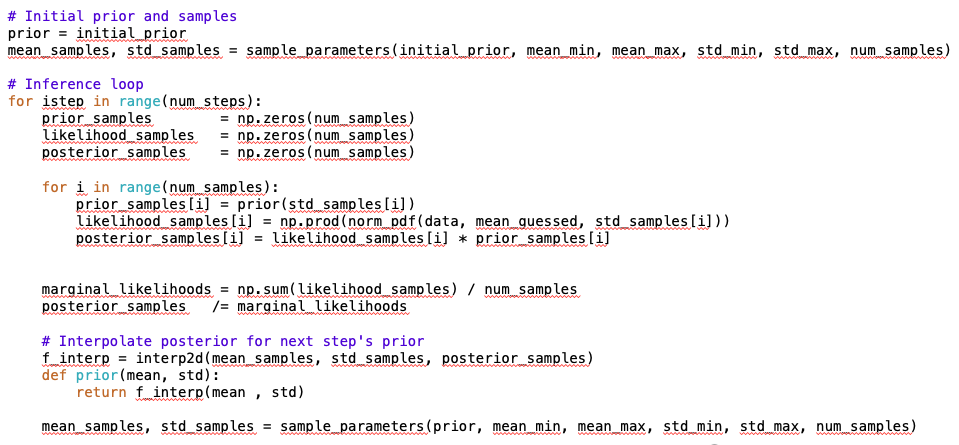

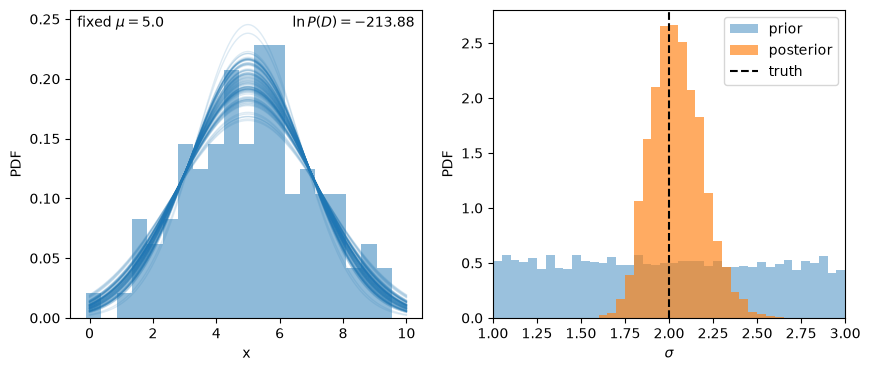

In [24]:
num_samples = 5000
mean_guessed = 5
xs = np.linspace(0, 10, 200)

# Drawing from the prior already accounts for the prior factor in Bayes' rule.
std_prior_samples = sample_parameters(
    initial_prior, std_min, std_max, num_samples
)

# Evaluate the full-data log-likelihood for every prior sample.
log_likelihood_samples = np.zeros(num_samples)
for i, std in enumerate(std_prior_samples):
    log_likelihood_samples[i] = np.sum(
        np.log(likelihood(data, mean_guessed, std))
    )

# Estimate P(D) by Monte Carlo and normalize the importance weights.
log_normalization = logsumexp(log_likelihood_samples)
log_evidence = log_normalization - np.log(num_samples)
log_weights = log_likelihood_samples - log_normalization
posterior_weights = np.exp(log_weights)

# Equal-weight draws that approximate the posterior.
std_posterior_samples = np.random.choice(
    std_prior_samples, size=num_samples, replace=True, p=posterior_weights
)

# Plot the data and model curves drawn from the posterior.
fig, axs = plt.subplots(1, 2, figsize=(10, 4))
axs[0].hist(data, bins=20, alpha=0.5, density=True, label='data')
for std in np.random.choice(std_posterior_samples, size=100):
    axs[0].plot(xs, norm_pdf(xs, mean_guessed, std),
                lw=1, alpha=0.15, color='tab:blue')
axs[0].set_xlabel('x')
axs[0].set_ylabel('PDF')
axs[0].text(0.98, 0.98, rf'$\ln P(D)={log_evidence:.2f}$',
            ha='right', va='top', transform=axs[0].transAxes)
axs[0].text(0.02, 0.98, rf'fixed $\mu={mean_guessed:.1f}$',
            ha='left', va='top', transform=axs[0].transAxes)

# Compare samples from the prior and posterior.
axs[1].hist(std_prior_samples, bins=40, range=(std_min, std_max),
            density=True, alpha=0.45, label='prior')
axs[1].hist(std_posterior_samples, bins=40, range=(std_min, std_max),
            density=True, alpha=0.65, label='posterior')
axs[1].axvline(std_real, color='k', linestyle='--', label='truth')
axs[1].set_xlim(std_min, std_max)
axs[1].set_xlabel(r'$\sigma$')
axs[1].set_ylabel('PDF')
axs[1].legend();

Change `mean_guessed` and observe how the marginal likelihood changes. A mean that describes the data poorly should have lower evidence.

> **Important:** the full dataset is used exactly once in this update. Reapplying the same likelihood to the resampled posterior would count the same data repeatedly and produce an artificially narrow distribution. Genuine sequential inference instead uses new, independent data at each update (or a properly defined tempering schedule).
